# Notebook 1 — Data Cleaning & ELO Calculation

1. **Load and clean** all raw data sources so they are consistent and ready to use.
2. **Calculate ELO ratings** for every national team across all matches in history, using FIFA's official SUM algorithm.

---
## 1. Imports & Paths

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

DATA_DIR   = Path('international_matches')
WC_DIR     = Path('world_cup_matches')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [4]:
results      = pd.read_csv(DATA_DIR / 'results.csv', parse_dates=['date'])
former_names = pd.read_csv(DATA_DIR / 'former_names.csv')
wc_matches   = pd.read_csv(WC_DIR   / 'matches_1930_2022.csv')
fifa_rank    = pd.read_csv(WC_DIR   / 'fifa_ranking_2026-06-08.csv')

print('results:     ', results.shape)
print('former_names:', former_names.shape)
print('wc_matches:  ', wc_matches.shape)
print('fifa_rank:   ', fifa_rank.shape)

results:      (49450, 9)
former_names: (36, 4)
wc_matches:   (964, 44)
fifa_rank:    (211, 8)


---
## 2. Load Raw Data

We have three main sources:
- **`results.csv`** — every international match from 1872 to 2026
- **`matches_1930_2022.csv`** — World Cup match data
- **`fifa_ranking_2026-06-08.csv`** — the current FIFA ranking

We also have `former_names.csv` which maps historical country names (e.g. "West Germany") to their modern equivalents — important for ELO continuity.

In [5]:
results.head(3)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0000,0.0000,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0000,2.0000,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0000,1.0000,Friendly,Glasgow,Scotland,False


In [6]:
former_names.head(10)

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01
5,Czechoslovakia,Representation of Czechs and Slovaks,1993-03-24,1993-11-17
6,DR Congo,Belgian Congo,1948-05-25,1956-01-02
7,DR Congo,Congo-Léopoldville,1963-04-12,1964-07-19
8,DR Congo,Congo-Kinshasa,1965-01-09,1970-11-24
9,DR Congo,Zaïre,1971-01-10,1997-04-27


---
## 3. Clean `results.csv`

### 3a. Drop rows with missing scores

72 rows have no score recorded — these are either future matches or data gaps. We cannot use them for ELO calculation.

In [7]:
print('Rows with missing scores:', results[['home_score', 'away_score']].isnull().any(axis=1).sum())
results = results.dropna(subset=['home_score', 'away_score']).copy()

# Scores should be integers
results['home_score'] = results['home_score'].astype(int)
results['away_score'] = results['away_score'].astype(int)

print('Remaining rows:', len(results))

Rows with missing scores: 72
Remaining rows: 49378


### 3b. Normalise team names using `former_names.csv`

Some teams changed their name over time (Soviet Union → Russia, West Germany → Germany, etc.).  
If we leave these as-is, we would track two separate ELO histories for what is effectively the same football programme.  
We map every historical name to its current successor **before** calculating ELO.

In [8]:
former_names.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


In [9]:
# Build a dictionary: {former_name: current_name}
# Columns: current, former, start_date, end_date
name_map = dict(zip(former_names['former'], former_names['current']))
print(f'Mappings loaded: {len(name_map)}')
print(dict(list(name_map.items())[:10]))

Mappings loaded: 36
{'Dahomey': 'Benin', 'Upper Volta': 'Burkina Faso', 'Netherlands Antilles': 'Curaçao', 'Bohemia': 'Czechoslovakia', 'Bohemia and Moravia': 'Czechoslovakia', 'Representation of Czechs and Slovaks': 'Czechoslovakia', 'Belgian Congo': 'DR Congo', 'Congo-Léopoldville': 'DR Congo', 'Congo-Kinshasa': 'DR Congo', 'Zaïre': 'DR Congo'}


In [10]:
results['home_team'] = results['home_team'].replace(name_map)
results['away_team'] = results['away_team'].replace(name_map)

# Confirm: how many unique teams do we now have?
all_teams = pd.unique(results[['home_team', 'away_team']].values.ravel())
print(f'Unique teams after normalisation: {len(all_teams)}')

Unique teams after normalisation: 336


### 3c. Sort chronologically

ELO is a sequential algorithm — each match updates the ratings **in order**. The data must be sorted by date before we do anything else.

In [11]:
results = results.sort_values('date').reset_index(drop=True)
print('Date range:', results['date'].min().date(), '→', results['date'].max().date())

Date range: 1872-11-30 → 2026-06-08


### 3d. Quick data quality check

In [12]:
print('Missing values after cleaning:')
print(results.isnull().sum())
print()
print('Sample rows:')
results.sample(5, random_state=42)

Missing values after cleaning:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

Sample rows:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
18148,1992-02-19,Spain,Russia,1,1,Friendly,Valencia,Spain,False
10072,1975-04-02,Italy,United States,10,0,Friendly,Rome,Italy,False
43809,2021-03-27,Lesotho,Sierra Leone,0,0,African Cup of Nations qualification,Maseru,Lesotho,False
38841,2015-06-16,Poland,Greece,0,0,Friendly,Gdańsk,Poland,False
42550,2019-06-09,Mexico,Ecuador,3,2,Friendly,Arlington,United States,True


---
## 4. Map Tournaments to FIFA Importance Weights (I)

FIFA's SUM algorithm weights each match by its competitive importance (I).  
The official scale is:

| I | Match type |
|---|---|
| 0.5 | Friendly **outside** an International Match Calendar (IMC) window |
| 1.0 | Friendly **inside** an IMC window |
| 1.5 | Nations League group stage |
| 2.5 | Nations League play-offs/finals; WC/confederation **qualification** |
| 3.5 | Confederation final competition (up to QF) |
| 4.0 | Confederation final competition (QF onwards); FIFA Confederations Cup |
| 5.0 | FIFA World Cup (up to QF) |
| 6.0 | FIFA World Cup (QF onwards) |

We cannot reliably know which friendlies fell inside an IMC window for all historical data, so we will treat all friendlies as **I = 1.0** (a conservative middle ground).  
We also cannot distinguish group stage from QF+ for every tournament, so we will use a single weight per competition type for now — this can be refined later.

> **Note:** For the World Cup and major confederation finals, we **do** have round data in `matches_1930_2022.csv`, so in the model training notebook we can apply the full 5.0/6.0 split.

In [13]:
# fmt: off
TOURNAMENT_WEIGHTS = {
    # ── Friendlies ──────────────────────────────────────────────────────────
    'Friendly':                                        1.0,
    'FIFA Series':                                     1.0,

    # ── Nations Leagues (group stage weight) ────────────────────────────────
    'UEFA Nations League':                             1.5,
    'CONCACAF Nations League':                         1.5,
    'CONCACAF Nations League qualification':           1.5,

    # ── World Cup & Confederation Qualification ──────────────────────────────
    'FIFA World Cup qualification':                    2.5,
    'UEFA Euro qualification':                         2.5,
    'African Cup of Nations qualification':            2.5,
    'AFC Asian Cup qualification':                     2.5,
    'Gold Cup qualification':                          2.5,
    'Oceania Nations Cup qualification':               2.5,
    'CONCACAF Championship qualification':             2.5,
    'Copa América qualification':                      2.5,
    'Arab Cup qualification':                          2.5,
    'COSAFA Cup qualification':                        2.5,
    'AFF Championship qualification':                  2.5,
    'EAFF Championship qualification':                 2.5,
    'AFC Challenge Cup qualification':                 2.5,
    'ASEAN Championship qualification':                2.5,

    # ── Confederation Finals ─────────────────────────────────────────────────
    # Using 3.5 as the default (group-stage weight); QF+ rounds handled separately later
    'UEFA Euro':                                       3.5,
    'Copa América':                                    3.5,
    'African Cup of Nations':                          3.5,
    'AFC Asian Cup':                                   3.5,
    'Gold Cup':                                        3.5,
    'CONCACAF Championship':                           3.5,
    'Oceania Nations Cup':                             3.5,
    'AFF Championship':                                3.5,
    'EAFF Championship':                               3.5,
    'AFC Challenge Cup':                               3.5,
    'WAFF Championship':                               3.5,
    'SAFF Cup':                                        3.5,
    'CAFA Nations Cup':                                3.5,
    'Gulf Cup':                                        3.5,
    'CFU Caribbean Cup':                               3.5,
    'UNCAF Cup':                                       3.5,
    'Arab Cup':                                        3.5,
    'COSAFA Cup':                                      3.5,
    'CECAFA Cup':                                      3.5,
    'Pan American Championship':                       3.5,

    # ── Confederations Cup (treated as 4.0 per FIFA rules) ───────────────────
    'Confederations Cup':                              4.0,

    # ── FIFA World Cup ───────────────────────────────────────────────────────
    'FIFA World Cup':                                  5.0,   # refined per round later
}

DEFAULT_WEIGHT = 1.0   # fallback for any tournament not listed above

results['importance'] = results['tournament'].map(TOURNAMENT_WEIGHTS).fillna(DEFAULT_WEIGHT)

print('Weight distribution:')
print(results['importance'].value_counts().sort_index())

Weight distribution:
importance
1.0000    25820
1.5000     1148
2.5000    15248
3.5000     6058
4.0000      140
5.0000      964
Name: count, dtype: int64


---
## 5. FIFA SUM ELO Algorithm

### How it works

FIFA's algorithm is a variant of the classic Elo rating system. After every match:

$$P_{\text{new}} = P_{\text{before}} + I \times (W - W_e)$$

**Variables:**
- $P_{\text{before}}$ — the team's rating before the match
- $I$ — match importance (from the table above)
- $W$ — actual result: **1** (win), **0.5** (draw), **0** (loss)
- $W_e$ — expected result (probability of winning), computed as:

$$W_e = \frac{1}{10^{-dr/600} + 1}$$

where $dr = P_{\text{before, Team A}} - P_{\text{before, Team B}}$

This is a sigmoid function — if two teams are equal ($dr = 0$), each has a 50% expected win probability. A team rated 600 points higher has roughly a 91% expected win probability.

**Starting ratings:** All teams start at **1000 points** (FIFA's baseline). Teams that have played more matches will naturally diverge from this.

In [14]:
def expected_result(rating_a, rating_b):
    """We for Team A given ratings of both teams."""
    dr = rating_a - rating_b
    return 1 / (10 ** (-dr / 600) + 1)


# Quick sanity check — symmetric probabilities
for delta in [0, 100, 300, 600]:
    we_a = expected_result(1000 + delta, 1000)
    we_b = expected_result(1000, 1000 + delta)
    print(f'dr={delta:+4d}  →  We(A)={we_a:.3f}  We(B)={we_b:.3f}  sum={we_a+we_b:.3f}')

dr=  +0  →  We(A)=0.500  We(B)=0.500  sum=1.000
dr=+100  →  We(A)=0.595  We(B)=0.405  sum=1.000
dr=+300  →  We(A)=0.760  We(B)=0.240  sum=1.000
dr=+600  →  We(A)=0.909  We(B)=0.091  sum=1.000


### 5a. Running the ELO calculation

We iterate through every match in chronological order.  
For each match we:
1. Look up both teams' current ratings (defaulting to 1000 if unseen)
2. Compute $W_e$ for both
3. Compute $W$ from the score
4. Update both ratings
5. Record the **pre-match** ratings (useful for features later)

We store the pre-match ELO in the `results` DataFrame so every row knows what both teams' ratings were going in.

In [15]:
INITIAL_RATING = 1000.0

elo_ratings = {}   # {team_name: current_rating}

home_elo_before = []
away_elo_before = []
home_elo_after  = []
away_elo_after  = []

for _, row in results.iterrows():
    home = row['home_team']
    away = row['away_team']
    I    = row['importance']

    r_home = elo_ratings.get(home, INITIAL_RATING)
    r_away = elo_ratings.get(away, INITIAL_RATING)

    # Record pre-match ratings
    home_elo_before.append(r_home)
    away_elo_before.append(r_away)

    # Expected results
    we_home = expected_result(r_home, r_away)
    we_away = expected_result(r_away, r_home)   # = 1 - we_home

    # Actual results
    if row['home_score'] > row['away_score']:
        w_home, w_away = 1.0, 0.0
    elif row['home_score'] < row['away_score']:
        w_home, w_away = 0.0, 1.0
    else:
        w_home, w_away = 0.5, 0.5

    # Update ratings
    r_home_new = r_home + I * (w_home - we_home)
    r_away_new = r_away + I * (w_away - we_away)

    elo_ratings[home] = r_home_new
    elo_ratings[away] = r_away_new

    home_elo_after.append(r_home_new)
    away_elo_after.append(r_away_new)

results['home_elo_before'] = home_elo_before
results['away_elo_before'] = away_elo_before
results['home_elo_after']  = home_elo_after
results['away_elo_after']  = away_elo_after

print('ELO columns added. Sample:')
results[['date','home_team','away_team','home_score','away_score',
          'home_elo_before','away_elo_before','home_elo_after','away_elo_after']].tail(5)

ELO columns added. Sample:


,date,home_team,away_team,home_score,away_score,home_elo_before,away_elo_before,home_elo_after,away_elo_after
49373,2026-06-07,Greece,Italy,0,1,1031.0278,1191.3510,1030.6769,1191.7018
49374,2026-06-08,Netherlands,Uzbekistan,2,1,1185.0407,1070.3494,1185.4324,1069.9577
49375,2026-06-08,Peru,Spain,1,3,974.4051,1227.9612,974.1309,1228.2354
49376,2026-06-08,France,Northern Ireland,3,1,1196.8278,949.9913,1197.1073,949.7118
49377,2026-06-08,Mauritania,Niger,1,0,938.9628,947.4098,939.4709,946.9017


---
## 6. Explore the ELO Ratings

### 6a. Current top-rated teams

In [16]:
current_elo = (
    pd.DataFrame(elo_ratings.items(), columns=['team', 'elo'])
    .sort_values('elo', ascending=False)
    .reset_index(drop=True)
)

print('Top 20 teams by current ELO:')
current_elo.head(20)

Top 20 teams by current ELO:


,team,elo
0,Brazil,1262.1917
1,Germany,1236.2266
2,Spain,1228.2354
3,Argentina,1217.7981
4,England,1202.0616
5,France,1197.1073
6,Italy,1191.7018
7,Netherlands,1185.4324
8,Iran,1172.1286
9,Mexico,1166.5513


### 6b. ELO history for selected teams

Let's plot how the ELO of a few historically strong teams evolved over time.

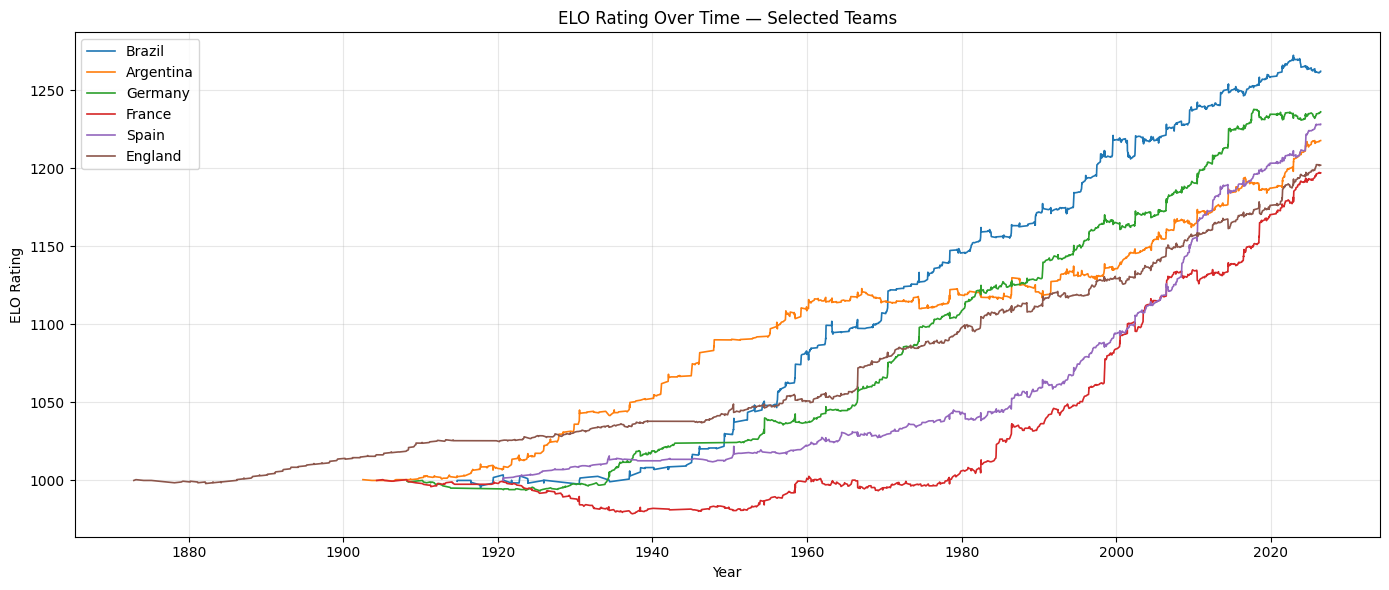

In [17]:
TEAMS_TO_PLOT = ['Brazil', 'Argentina', 'Germany', 'France', 'Spain', 'England']

fig, ax = plt.subplots(figsize=(14, 6))

for team in TEAMS_TO_PLOT:
    mask = (results['home_team'] == team) | (results['away_team'] == team)
    sub  = results[mask].copy()
    # Use the post-match rating for the team
    sub['team_elo'] = np.where(sub['home_team'] == team, sub['home_elo_after'], sub['away_elo_after'])
    ax.plot(sub['date'], sub['team_elo'], label=team, linewidth=1.2)

ax.set_title('ELO Rating Over Time — Selected Teams')
ax.set_xlabel('Year')
ax.set_ylabel('ELO Rating')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6c. Distribution of current ELO ratings

Most teams cluster near the 1000 baseline. Outliers at the top represent the elite nations.

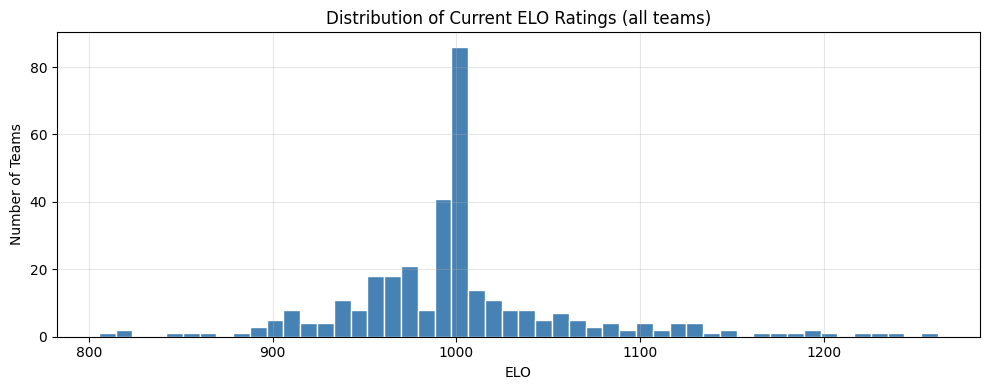

count    336.0000
mean    1000.0000
std       63.4970
min      805.3062
25%      968.4913
50%      998.5077
75%     1012.6103
max     1262.1917
Name: elo, dtype: float64


In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(current_elo['elo'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Current ELO Ratings (all teams)')
ax.set_xlabel('ELO')
ax.set_ylabel('Number of Teams')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(current_elo['elo'].describe())

---
## 7. Save Outputs

We save two files that future notebooks will load:

- **`results_with_elo.csv`** — the full match history with pre- and post-match ELO for both teams.
- **`current_elo.csv`** — each team's most recent ELO rating (as of the last match in the dataset).

In [ ]:
results.to_csv(OUTPUT_DIR / 'results_with_elo.csv', index=False)
current_elo.to_csv(OUTPUT_DIR / 'current_elo.csv', index=False)

print('Saved:')
print(f'  output/results_with_elo.csv  ({len(results):,} rows)')
print(f'  output/current_elo.csv       ({len(current_elo):,} teams)')

---
## What's next?

In **Notebook 2** we will build on this by:
- Computing **recent form** (last N matches): win rate, goals scored/conceded
- Computing **competitive form** separately (filtering out friendlies)
- Assembling a clean **match-pair feature table** where each row is one match with ΔELO, Δform, FIFA rank, etc. — ready to feed into a model.